# Analisi risultati regressione

Statistiche descrittive (media, deviazione standard) e boxplot per modello su ciascun foglio di `new_results/results_regression.xlsx`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
BASE_DIR = Path(".").resolve()
RESULTS_PATH = BASE_DIR / "results" / "run_v5.3" / "results_regression.xlsx"
FIGURES_DIR = BASE_DIR / "results"  / "run_v5.3" / "figures_regression"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ["MAE", "MSE", "RMSE", "R2", "MAPE", "MEDAE", "EVS"]
MODEL_ORDER = ["XGBoost", "LightGBM", "DT", "SVR"]

assert RESULTS_PATH.exists(), f"File non trovato: {RESULTS_PATH}"

In [3]:
sheets = pd.read_excel(RESULTS_PATH, sheet_name=None)
print("Fogli disponibili:", list(sheets.keys()))
for name, df in sheets.items():
    print(f"  {name}: {df.shape[0]} righe, modelli = {df['Model'].unique().tolist()}")

Fogli disponibili: ['sis', 'oks', 'ohs']
  sis: 90 righe, modelli = ['XGBoost', 'CatBoost', 'LightGBM', 'DecisionTreeRegressor (DT)', 'SVR']
  oks: 90 righe, modelli = ['XGBoost', 'CatBoost', 'LightGBM', 'DecisionTreeRegressor (DT)', 'SVR']
  ohs: 90 righe, modelli = ['XGBoost', 'CatBoost', 'LightGBM', 'DecisionTreeRegressor (DT)', 'SVR']


## Media e deviazione standard per modello

In [4]:
def summary_by_model(df: pd.DataFrame) -> pd.DataFrame:
    """Media e std per ogni metrica, raggruppate per Model."""
    stats = df.groupby("Model", observed=True)[METRICS].agg(["mean", "std"])
    stats = stats.reindex(MODEL_ORDER)
    stats.columns = [f"{metric}_{stat}" for metric, stat in stats.columns]
    return stats.round(4)


summary_tables = {}
for sheet_name, df in sheets.items():
    summary_tables[sheet_name] = summary_by_model(df)
    print(f"\n=== {sheet_name.upper()} ===")
    display(summary_tables[sheet_name])


=== SIS ===


,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAPE_mean,MAPE_std,MEDAE_mean,MEDAE_std,EVS_mean,EVS_std
Model,,,,,,,,,,,,,,
XGBoost,3.4246,1.5688,16.7123,13.9798,3.7700,1.6268,-14.3211,25.8429,0.1566,0.0980,3.4939,1.7515,-0.5947,1.5017
LightGBM,3.4267,1.5256,16.5918,14.1507,3.7694,1.5886,-14.0112,25.4923,0.1569,0.0971,3.4876,1.7364,-0.6830,1.5999
DT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SVR,3.4746,1.6037,17.9400,14.4552,3.9181,1.6556,-17.9957,34.2302,0.1582,0.0886,3.4233,1.7458,-1.8899,3.0671



=== OKS ===


,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAPE_mean,MAPE_std,MEDAE_mean,MEDAE_std,EVS_mean,EVS_std
Model,,,,,,,,,,,,,,
XGBoost,8.3895,5.3128,105.1314,104.7542,8.9778,5.0964,-18.1989,27.5881,0.3055,0.1957,8.2303,5.8124,-0.0026,0.0272
LightGBM,8.6043,5.5802,111.5278,115.3545,9.1858,5.3614,-20.0759,31.7570,0.3136,0.2040,8.3924,6.0614,-0.0389,0.2110
DT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SVR,8.2062,5.4819,103.1244,115.2860,8.7701,5.2680,-16.7399,23.7579,0.2862,0.1698,8.1524,5.7879,-0.1214,0.1961



=== OHS ===


,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAPE_mean,MAPE_std,MEDAE_mean,MEDAE_std,EVS_mean,EVS_std
Model,,,,,,,,,,,,,,
XGBoost,6.5204,4.8292,72.1877,85.9600,7.1209,4.7691,-18.0641,31.6527,0.2488,0.1787,6.4698,5.1196,0.0060,0.0649
LightGBM,6.4947,4.8334,71.9133,86.0983,7.0983,4.7742,-18.1344,31.9748,0.2475,0.1777,6.4704,5.1405,0.0614,0.2353
DT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SVR,6.2496,4.7702,67.6906,86.3137,6.8096,4.7512,-16.5915,31.6595,0.2327,0.1606,6.1399,4.8965,-0.1578,0.3770


## Boxplot: confronto modelli (per foglio)

Ogni figura mostra tutte le metriche per un singolo outcome (foglio). I modelli sono sull'asse x; ogni box riassume la distribuzione su pazienti e fold CV.

Salvato: C:\Users\Alessio\HOME\Git Projects (local)\MAISON-ML\results\run_v5.3\figures_regression\boxplot_models_sis.png


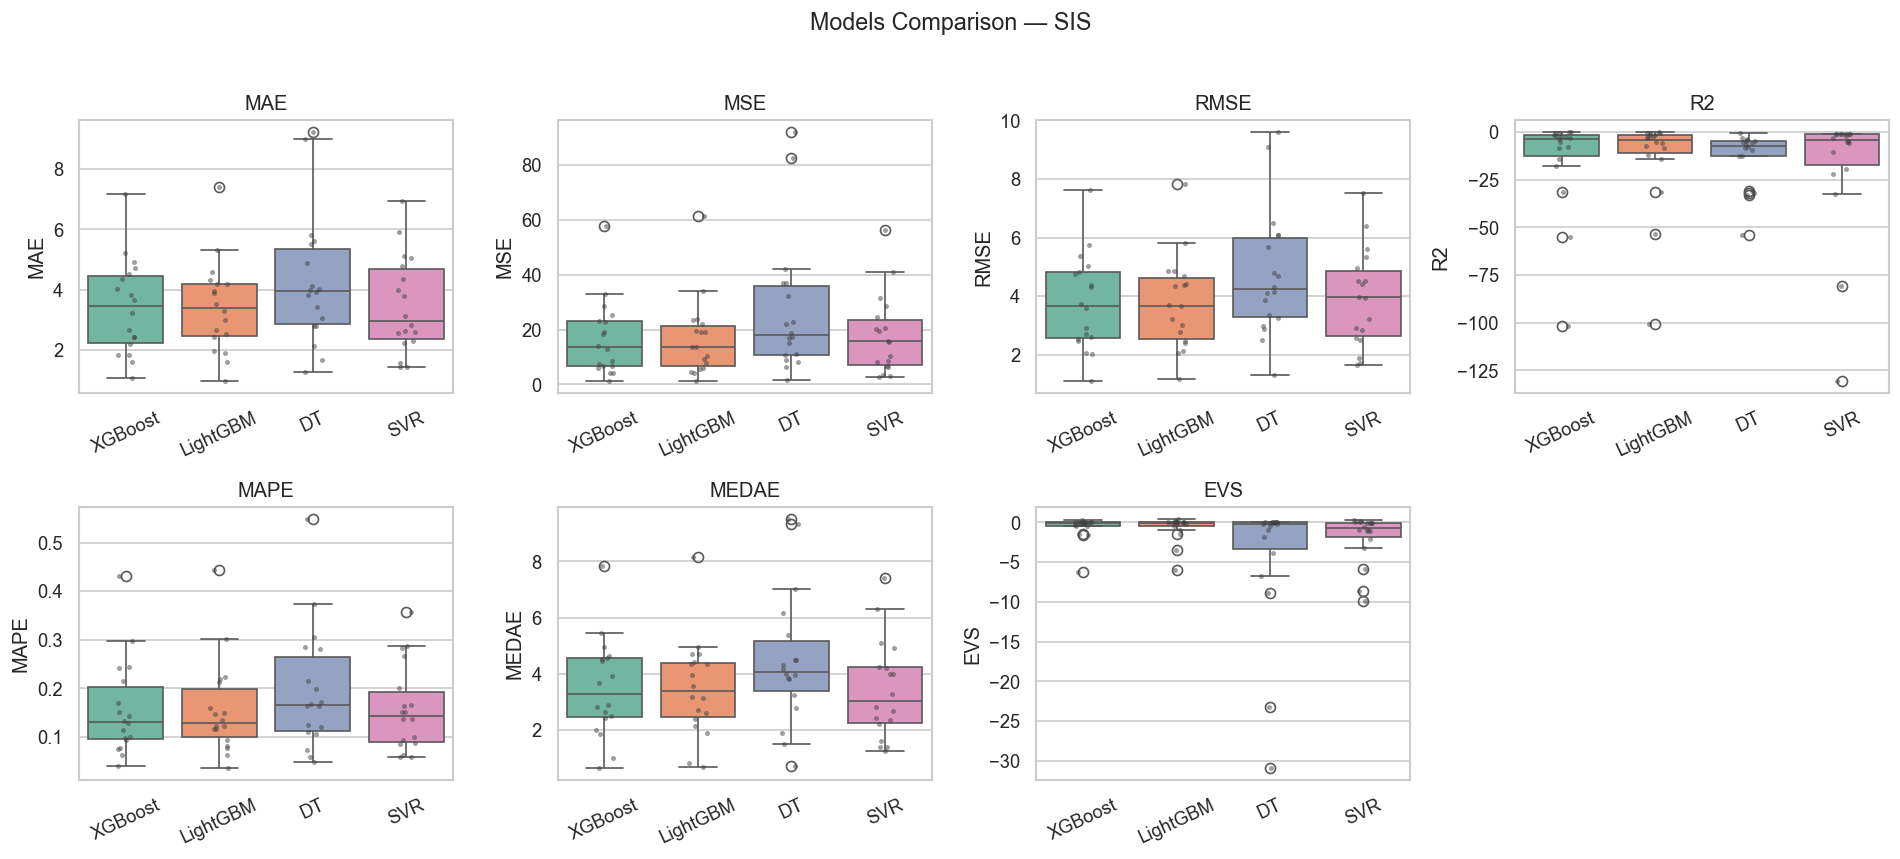

Salvato: C:\Users\Alessio\HOME\Git Projects (local)\MAISON-ML\results\run_v5.3\figures_regression\boxplot_models_oks.png


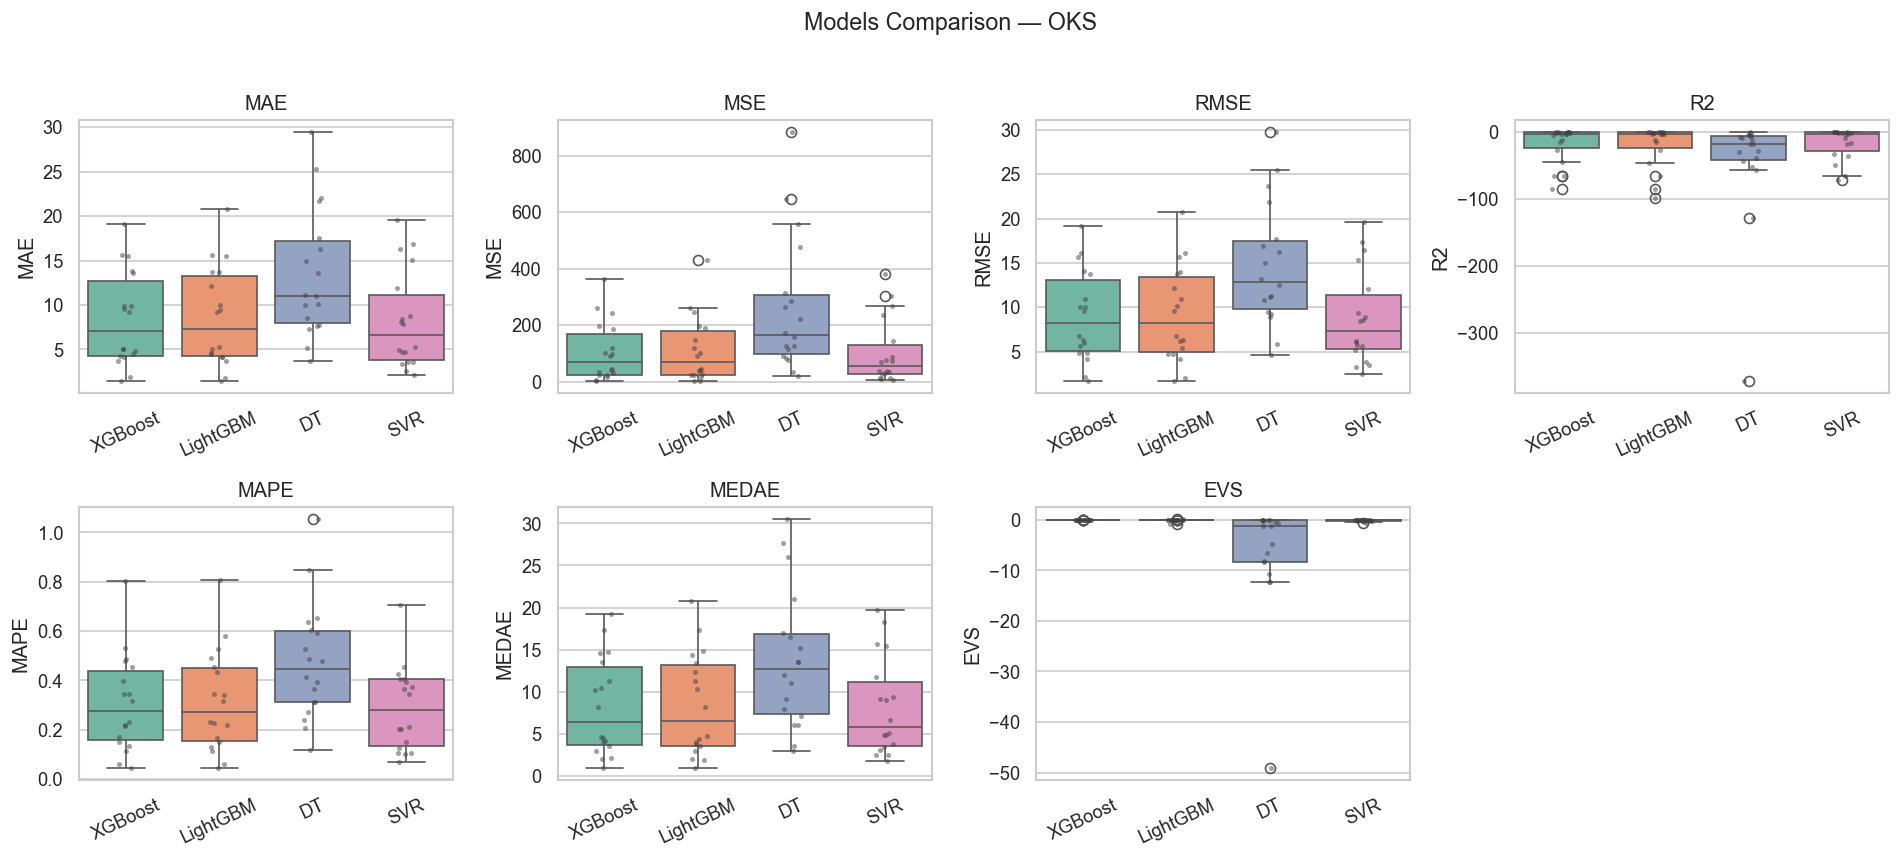

Salvato: C:\Users\Alessio\HOME\Git Projects (local)\MAISON-ML\results\run_v5.3\figures_regression\boxplot_models_ohs.png


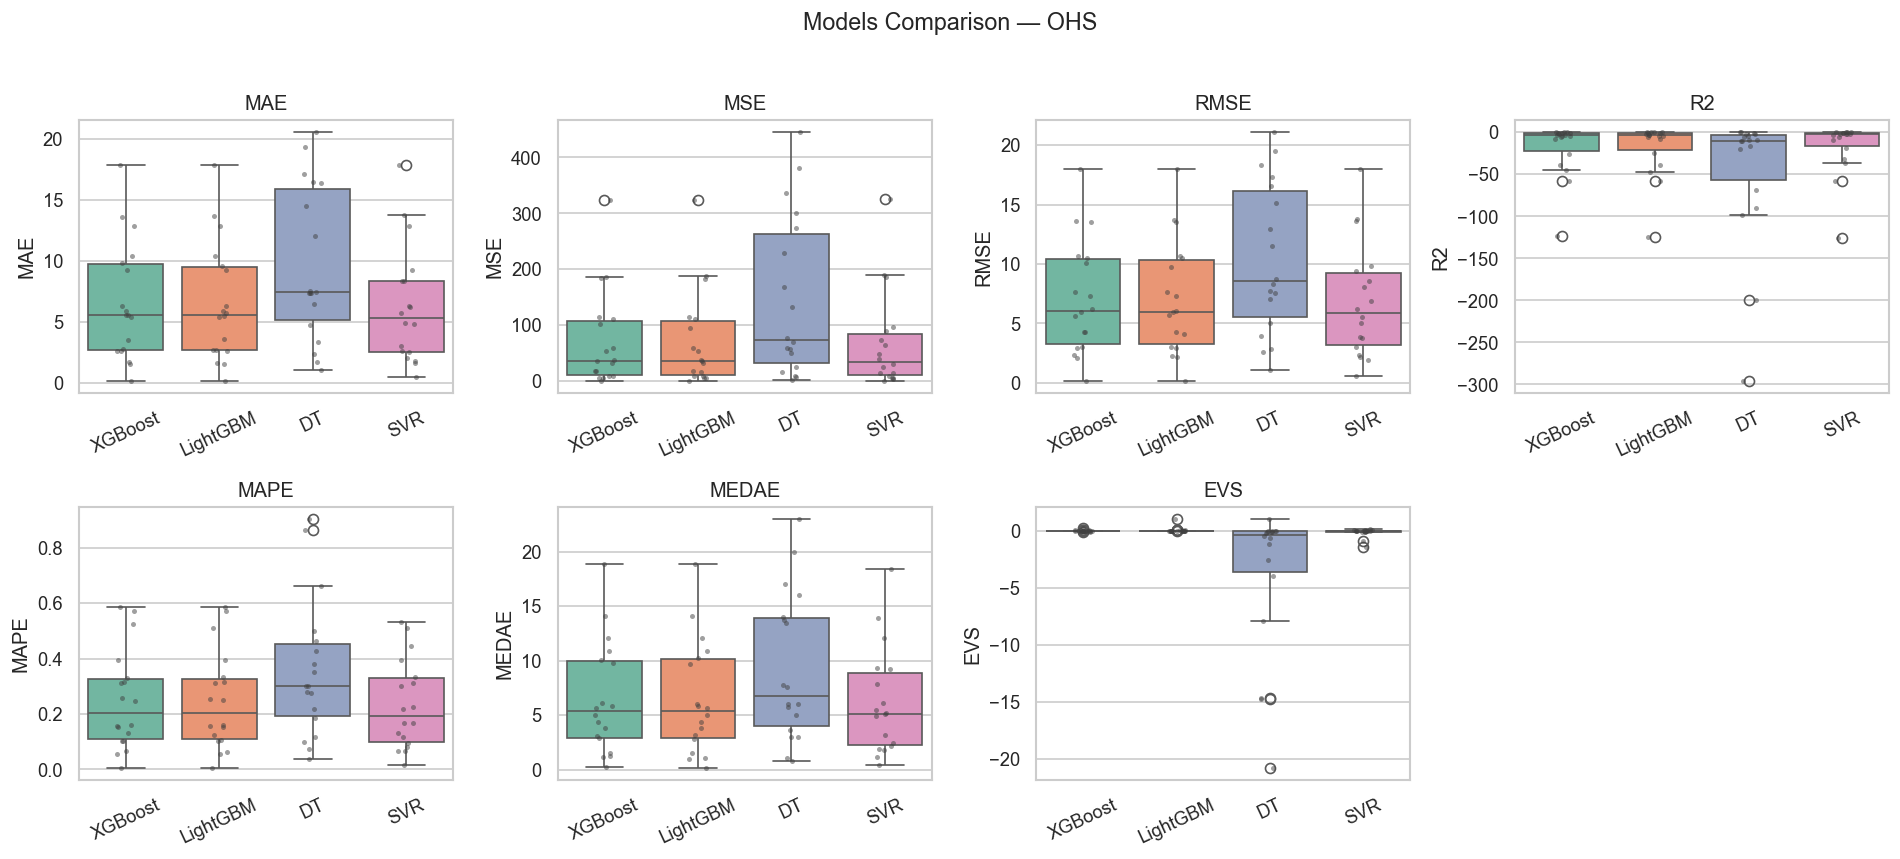

In [5]:
def plot_model_boxplots(df: pd.DataFrame, sheet_name: str, save: bool = True) -> None:
    plot_df = df.copy()
    plot_df["Model"] = plot_df["Model"].replace({"DecisionTreeRegressor (DT)": "DT"})
    plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=["XGBoost", "LightGBM", "DT", "SVR"], ordered=True)
    plot_df = plot_df.sort_values("Model")

    n_metrics = len(METRICS)
    n_cols = 4
    n_rows = (n_metrics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten()

    for ax, metric in zip(axes, METRICS):
        sns.boxplot(
            data=plot_df,
            x="Model",
            y=metric,
            order=["XGBoost", "LightGBM", "DT", "SVR"],
            hue="Model",
            palette="Set2",
            legend=False,
            ax=ax,
        )
        sns.stripplot(
            data=plot_df,
            x="Model",
            y=metric,
            order=["XGBoost", "LightGBM", "DT", "SVR"],
            color="0.25",
            size=3,
            alpha=0.5,
            ax=ax,
        )
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)

    for ax in axes[n_metrics:]:
        ax.set_visible(False)

    fig.suptitle(f"Models Comparison — {sheet_name.upper()}", fontsize=14, y=1.02)
    fig.tight_layout()

    if save:
        out_path = FIGURES_DIR / f"boxplot_models_{sheet_name}.png"
        fig.savefig(out_path, bbox_inches="tight")
        print(f"Salvato: {out_path}")

    plt.show()


for sheet_name, df in sheets.items():
    plot_model_boxplots(df, sheet_name)

## Esportazione tabelle riassuntive (opzionale)

In [6]:
summary_path = BASE_DIR / "results"  / "run_v5.3" / "summary_regression_stats.xlsx"
with pd.ExcelWriter(summary_path) as writer:
    for sheet_name, table in summary_tables.items():
        table.to_excel(writer, sheet_name=sheet_name)
print(f"Tabelle salvate in: {summary_path}")

Tabelle salvate in: C:\Users\Alessio\HOME\Git Projects (local)\MAISON-ML\results\run_v5.3\summary_regression_stats.xlsx
